
KARAWANG PADI GUARD - RISK PREDICTION TRAINING
Start Time: 2026-04-28 17:03:42



W&B Project: karawang-padi-guard
W&B Run Name: xgboost_risk_prediction_v1
W&B Run ID: 6qnnh0ao

RUNTIME CONFIGURATION
Kaggle mode detected. Applied T4 defaults.
Weather data path: /kaggle/input/datasets/yesayasentosa/datathon-prediksi-produksi-padi/weather_data.csv
Production data path: /kaggle/input/datasets/yesayasentosa/datathon-prediksi-produksi-padi/dataset_produksi_padi_karawang_cleaned.csv
Output dir: /kaggle/working/models
Logs dir: /kaggle/working/logs
GPU enabled: True
n_estimators: 300
LOADING AND PREPARING DATA
Loaded weather data: (3388, 12)
Date range: 2024-01-01 00:00:00 to 2026-04-26 00:00:00

Engineering features...
Features created: 46

Calculating risk labels...


/tmp/ipykernel_55/1902517995.py:275: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['season_encoded'] = le.fit_transform(df['season'])



Final dataset shape: (3375, 48)

Risk distribution:
risk_category
Low       2163
Medium     898
High       314
Name: count, dtype: int64

Preparing features and target...
Feature matrix shape: (3375, 37)
Target vector shape: (3375,)

Splitting data...
Train set: (2700, 37)
Test set: (675, 37)

TRAINING XGBOOST MODEL
Using GPU acceleration for XGBoost (device=cuda)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:03:49] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:03:49] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:03:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained successfully!
Training iterations: 300

EVALUATING MODEL

Overall Metrics:
  Accuracy:  0.9837
  Precision: 0.9837
  Recall:    0.9837
  F1-Score:  0.9837

Classification Report:
              precision    recall  f1-score   support

         Low       0.98      0.99      0.98       271
      Medium       0.99      0.98      0.98       297
        High       0.98      1.00      0.99       107

    accuracy                           0.98       675
   macro avg       0.98      0.99      0.99       675
weighted avg       0.98      0.98      0.98       675


Confusion matrix saved to: /kaggle/working/models/xgboost_risk_prediction_v1_confusion_matrix.png
Feature importance plot saved to: /kaggle/working/models/xgboost_risk_prediction_v1_feature_importance.png

Top 10 Most Important Features:
                  feature  importance
       humidity_rolling_3    0.259075
       humidity_rolling_7    0.197172
                 humidity    0.155985
      humidity_rolling_14    0.0788

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.



SAVING MODEL AND ARTIFACTS
Model saved to: /kaggle/working/models/xgboost_risk_prediction_v1.pkl
Scaler saved to: /kaggle/working/models/xgboost_risk_prediction_v1_scaler.pkl
Feature names saved to: /kaggle/working/models/xgboost_risk_prediction_v1_features.json
Config saved to: /kaggle/working/models/xgboost_risk_prediction_v1_config.json
Metrics saved to: /kaggle/working/models/xgboost_risk_prediction_v1_metrics.json

TRAINING COMPLETE!

PREDICTING RISK FOR NEXT 7 DAYS

Next 7 days forecast generated

End Time: 2026-04-28 17:03:51

Training completed successfully!


test_accuracy,▁
test_f1_score,▁
test_precision,▁
test_recall,▁
test_accuracy,0.9837
test_f1_score,0.98369
test_precision,0.98372
test_recall,0.9837
timestamp,2026-04-28T17:03:51....


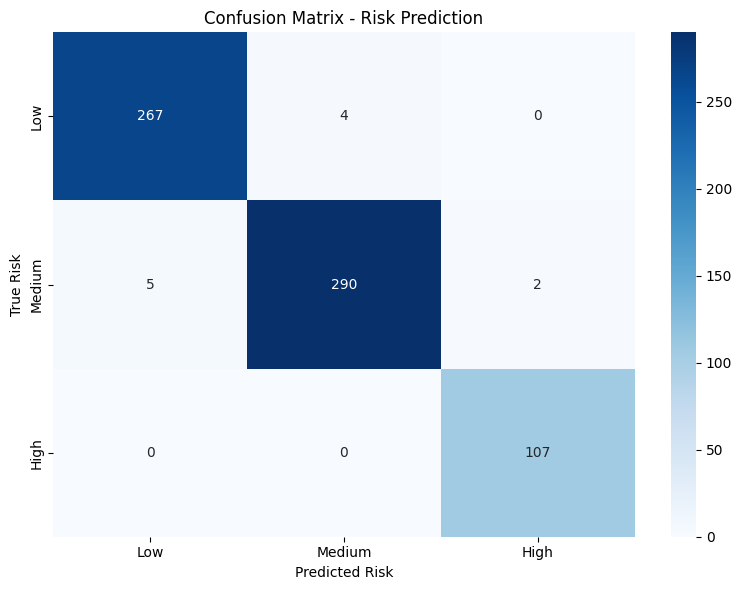

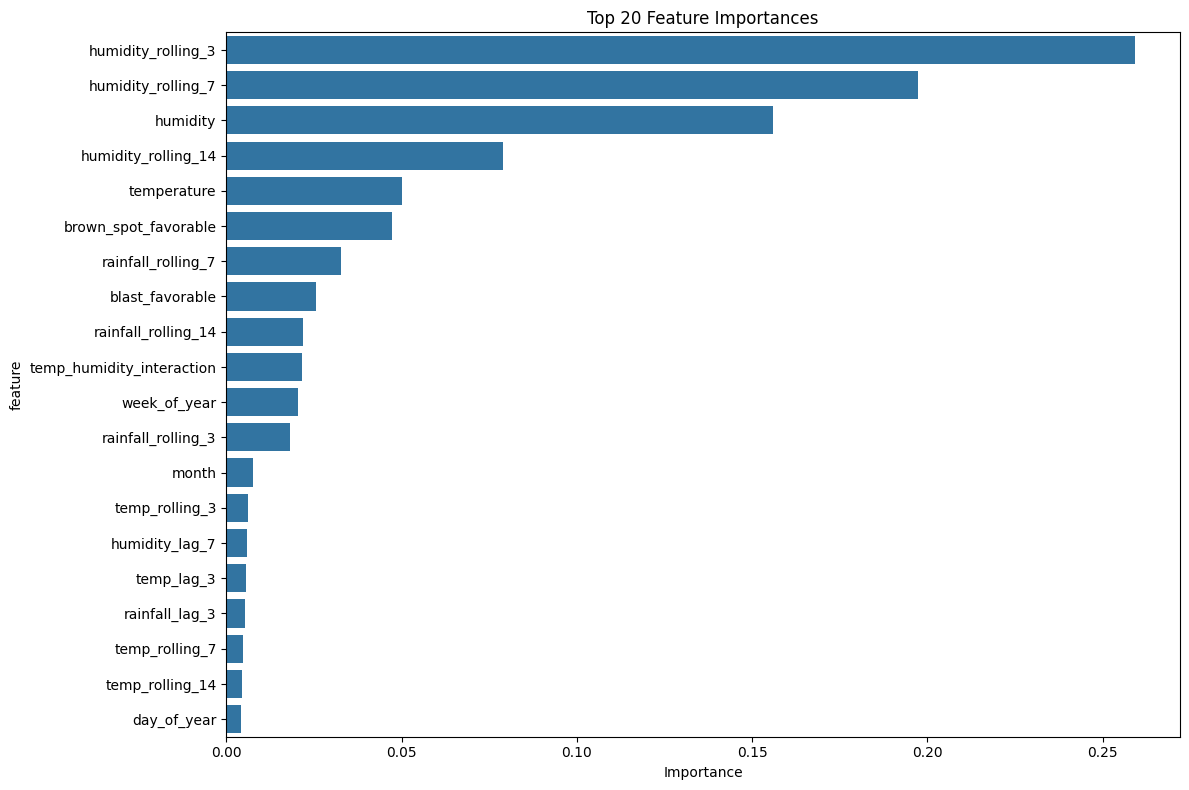

In [2]:
"""
Training Script for Risk Prediction Model (Tabular)
KarawangPadiGuard - Microsoft Elevate Datathon

Predicts disease risk based on weather patterns and historical data

Author: Yesaya Situmorang
Date: 2026-04-28
"""

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Monitoring
import wandb

# Configuration
CONFIG = {
    # Data paths
    'weather_data_path': '/kaggle/input/datasets/yesayasentosa/datathon-prediksi-produksi-padi/weather_data.csv',
    'production_data_path': '/kaggle/input/datasets/yesayasentosa/datathon-prediksi-produksi-padi/dataset_produksi_padi_karawang_cleaned.csv',
    'output_dir': './models',
    'logs_dir': './logs',

    # Model
    'model_name': 'xgboost_risk_prediction_v1',

    # Features
    'risk_threshold_humidity': 85,  # Above this humidity = high risk
    'risk_threshold_temp_min': 25,  # Min temp for disease
    'risk_threshold_temp_max': 32,  # Max temp for disease
    'risk_rainfall_threshold': 5,   # mm of rain

    # Risk categories
    'risk_categories': ['Low', 'Medium', 'High'],

    # Training
    'test_size': 0.2,
    'random_state': 42,
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_jobs': -1,
    'gpu_enabled': True,
    'predictor': 'auto',

    # Kaggle runtime defaults
    'kaggle_gpu_enabled': True,
    'kaggle_n_estimators': 300
}

# Disease-specific conditions
DISEASE_CONDITIONS = {
    'Blast': {
        'temp_min': 25,
        'temp_max': 28,
        'humidity_min': 90,
        'name': 'Leaf Blast (Pyricularia oryzae)'
    },
    'Brown_Spot': {
        'temp_min': 28,
        'temp_max': 32,
        'humidity_min': 85,
        'name': 'Brown Spot (Cochliobolus miyabeanus)'
    },
    'Bacterial_Blight': {
        'temp_min': 25,
        'temp_max': 30,
        'humidity_min': 85,
        'name': 'Bacterial Leaf Blight (Xanthomonas oryzae)'
    },
    'Sheath_Blight': {
        'temp_min': 28,
        'temp_max': 32,
        'humidity_min': 90,
        'name': 'Sheath Blight (Rhizoctonia solani)'
    }
}


def is_kaggle_environment():
    """Detect whether the script runs inside Kaggle."""
    return os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None or Path("/kaggle/input").exists()


def get_bool_env(var_name: str, default: bool) -> bool:
    """Read boolean environment variable with a safe default."""
    value = os.environ.get(var_name)
    if value is None:
        return default
    return value.strip().lower() in {'1', 'true', 'yes', 'y', 'on'}


def auto_detect_kaggle_csv(input_root: Path, preferred_keywords):
    """Find a likely CSV file from /kaggle/input using keyword ranking."""
    if not input_root.exists():
        return None

    candidates = [path for path in input_root.rglob("*.csv") if path.is_file()]
    if not candidates:
        return None

    candidates.sort(
        key=lambda p: (
            not all(keyword in p.name.lower() for keyword in preferred_keywords),
            not any(keyword in str(p).lower() for keyword in preferred_keywords),
            len(p.parts),
            p.name.lower(),
        )
    )
    return candidates[0]


def configure_runtime():
    """Configure paths and model defaults for Kaggle + GPU T4."""
    print("=" * 60)
    print("RUNTIME CONFIGURATION")
    print("=" * 60)

    kaggle_mode = is_kaggle_environment()
    if kaggle_mode:
        input_root = Path("/kaggle/input")
        weather_override = os.environ.get("KAGGLE_WEATHER_DATA_PATH")
        production_override = os.environ.get("KAGGLE_PRODUCTION_DATA_PATH")

        if weather_override:
            CONFIG['weather_data_path'] = weather_override
        elif CONFIG['weather_data_path'].startswith("./"):
            weather_detected = auto_detect_kaggle_csv(input_root, ("weather", "cuaca"))
            if weather_detected is not None:
                CONFIG['weather_data_path'] = str(weather_detected)

        if production_override:
            CONFIG['production_data_path'] = production_override
        elif CONFIG['production_data_path'].startswith("./"):
            production_detected = auto_detect_kaggle_csv(
                input_root, ("produksi", "production", "karawang")
            )
            if production_detected is not None:
                CONFIG['production_data_path'] = str(production_detected)

        CONFIG['output_dir'] = os.environ.get("KAGGLE_OUTPUT_DIR", "/kaggle/working/models")
        CONFIG['logs_dir'] = os.environ.get("KAGGLE_LOGS_DIR", "/kaggle/working/logs")
        CONFIG['gpu_enabled'] = get_bool_env("KAGGLE_GPU_ENABLED", CONFIG['kaggle_gpu_enabled'])
        CONFIG['n_estimators'] = int(os.environ.get("KAGGLE_N_ESTIMATORS", CONFIG['kaggle_n_estimators']))
        print("Kaggle mode detected. Applied T4 defaults.")

    print(f"Weather data path: {CONFIG['weather_data_path']}")
    print(f"Production data path: {CONFIG['production_data_path']}")
    print(f"Output dir: {CONFIG['output_dir']}")
    print(f"Logs dir: {CONFIG['logs_dir']}")
    print(f"GPU enabled: {CONFIG['gpu_enabled']}")
    print(f"n_estimators: {CONFIG['n_estimators']}")


def create_output_directories():
    """Create output directories if they don't exist"""
    Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
    Path(CONFIG['logs_dir']).mkdir(parents=True, exist_ok=True)


def load_and_prepare_data():
    """
    Load weather data and prepare features for risk prediction
    """
    print("=" * 60)
    print("LOADING AND PREPARING DATA")
    print("=" * 60)

    # Load weather data
    weather_path = Path(CONFIG['weather_data_path'])
    if not weather_path.exists():
        raise FileNotFoundError(f"Weather data not found at {weather_path}")

    df = pd.read_csv(weather_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    print(f"Loaded weather data: {df.shape}")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")

    # Feature engineering
    df = engineer_features(df)

    # Calculate risk labels
    df = calculate_risk_labels(df)

    print(f"\nFinal dataset shape: {df.shape}")
    print(f"\nRisk distribution:")
    print(df['risk_category'].value_counts())

    return df


def engineer_features(df):
    """
    Engineer features for risk prediction
    """
    print("\nEngineering features...")

    # Temporal features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(np.int32)
    df['season'] = df['month'].map({
        12: 'Rainy', 1: 'Rainy', 2: 'Rainy', 3: 'Rainy', 4: 'Rainy',
        5: 'Dry', 6: 'Dry', 7: 'Dry', 8: 'Dry', 9: 'Dry',
        10: 'Transitional', 11: 'Transitional'
    })

    # Lag features (previous days)
    for lag in [1, 3, 7]:
        df[f'temp_lag_{lag}'] = df['temperature'].shift(lag)
        df[f'humidity_lag_{lag}'] = df['humidity'].shift(lag)
        df[f'rainfall_lag_{lag}'] = df['rainfall'].shift(lag)

    # Rolling averages
    for window in [3, 7, 14]:
        df[f'temp_rolling_{window}'] = df['temperature'].rolling(window=window).mean()
        df[f'humidity_rolling_{window}'] = df['humidity'].rolling(window=window).mean()
        df[f'rainfall_rolling_{window}'] = df['rainfall'].rolling(window=window).sum()

    # Weather interactions
    df['temp_humidity_interaction'] = df['temperature'] * df['humidity']
    df['rain_intensity'] = pd.cut(df['rainfall'], bins=[-1, 0, 5, 20, float('inf')],
                                   labels=[0, 1, 2, 3]).astype(int)

    # Disease-specific indicators
    df['blast_favorable'] = (
        (df['temperature'] >= 25) & (df['temperature'] <= 28) &
        (df['humidity'] >= 90)
    ).astype(int)

    df['brown_spot_favorable'] = (
        (df['temperature'] >= 28) & (df['temperature'] <= 32) &
        (df['humidity'] >= 85)
    ).astype(int)

    # Cumulative rainfall (last 7 days)
    df['rainfall_7day_cum'] = df['rainfall'].rolling(7).sum()

    # Temperature trend
    df['temp_trend_3d'] = df['temperature'].diff(3)
    df['humidity_trend_3d'] = df['humidity'].diff(3)

    # Extreme conditions
    df['extreme_heat'] = (df['temperature'] > 32).astype(int)
    df['extreme_humidity'] = (df['humidity'] > 95).astype(int)
    df['heavy_rain'] = (df['rainfall'] > 20).astype(int)

    # Drop rows with NaN (from lag features)
    df = df.dropna()

    # Encode categorical
    le = LabelEncoder()
    df['season_encoded'] = le.fit_transform(df['season'])

    print(f"Features created: {df.shape[1]}")

    return df


def calculate_risk_labels(df):
    """
    Calculate risk labels based on weather conditions and disease patterns
    """
    print("\nCalculating risk labels...")

    conditions = []

    for _, row in df.iterrows():
        risk_score = 0

        # Check each disease condition
        for disease, condition in DISEASE_CONDITIONS.items():
            if (condition['temp_min'] <= row['temperature'] <= condition['temp_max'] and
                row['humidity'] >= condition['humidity_min']):
                risk_score += 1

        # Additional risk factors
        if row['rainfall_7day_cum'] > 30:
            risk_score += 1
        if row['humidity_rolling_7'] > 85:
            risk_score += 1

        # Categorize risk
        if risk_score >= 4:
            conditions.append('High')
        elif risk_score >= 2:
            conditions.append('Medium')
        else:
            conditions.append('Low')

    df['risk_category'] = conditions
    df['risk_score'] = [CONFIG['risk_categories'].index(c) for c in conditions]

    return df


def prepare_features_and_target(df):
    """
    Prepare feature matrix and target vector
    """
    print("\nPreparing features and target...")

    # Select features
    feature_cols = [
        # Current weather
        'temperature', 'humidity', 'rainfall', 'wind_speed', 'cloud_cover',

        # Temporal
        'month', 'day_of_year', 'week_of_year', 'season_encoded',

        # Lag features
        'temp_lag_1', 'humidity_lag_1', 'rainfall_lag_1',
        'temp_lag_3', 'humidity_lag_3', 'rainfall_lag_3',
        'temp_lag_7', 'humidity_lag_7', 'rainfall_lag_7',

        # Rolling features
        'temp_rolling_3', 'humidity_rolling_3', 'rainfall_rolling_3',
        'temp_rolling_7', 'humidity_rolling_7', 'rainfall_rolling_7',
        'temp_rolling_14', 'humidity_rolling_14', 'rainfall_rolling_14',

        # Interactions
        'temp_humidity_interaction', 'rain_intensity',
        'rainfall_7day_cum', 'temp_trend_3d', 'humidity_trend_3d',

        # Disease indicators
        'blast_favorable', 'brown_spot_favorable',

        # Extremes
        'extreme_heat', 'extreme_humidity', 'heavy_rain'
    ]

    X = df[feature_cols].copy()
    y = df['risk_score'].copy()

    print(f"Feature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")

    return X, y, feature_cols


def split_data(X, y):
    """
    Split data into train and test sets (time-based)
    """
    print("\nSplitting data...")

    # Time-based split (use last 20% for testing)
    split_idx = int(len(X) * (1 - CONFIG['test_size']))

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    print(f"Train set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_test_scaled = scaler.transform(X_test).astype(np.float32)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


def train_xgboost_model(X_train, y_train):
    """
    Train XGBoost classifier
    """
    print("\n" + "=" * 60)
    print("TRAINING XGBOOST MODEL")
    print("=" * 60)

    xgb_params = {
        'n_estimators': CONFIG['n_estimators'],
        'max_depth': CONFIG['max_depth'],
        'learning_rate': CONFIG['learning_rate'],
        'random_state': CONFIG['random_state'],
        'objective': 'multi:softmax',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'n_jobs': CONFIG.get('n_jobs', -1),
        'predictor': CONFIG.get('predictor', 'auto')
    }

    if CONFIG.get('gpu_enabled', True):
        xgb_params.update({
            'tree_method': 'hist',
            'device': 'cuda'
        })
        print("Using GPU acceleration for XGBoost (device=cuda)")
    else:
        xgb_params.update({'tree_method': 'hist'})
        print("Using CPU training for XGBoost")

    # Log hyperparameters to W&B
    wandb.config.update(xgb_params)
    wandb.config.update({
        'train_samples': X_train.shape[0],
        'num_features': X_train.shape[1]
    })

    model = xgb.XGBClassifier(**xgb_params)

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    print("Model trained successfully!")
    print(f"Training iterations: {model.n_estimators}")

    return model


def evaluate_model(model, X_test, y_test, feature_names):
    """
    Evaluate model performance
    """
    print("\n" + "=" * 60)
    print("EVALUATING MODEL")
    print("=" * 60)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("\nOverall Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    # Log metrics to W&B
    wandb.log({
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1_score': f1
    })

    # Classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=CONFIG['risk_categories']
    ))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CONFIG['risk_categories'],
        yticklabels=CONFIG['risk_categories']
    )
    plt.title('Confusion Matrix - Risk Prediction')
    plt.ylabel('True Risk')
    plt.xlabel('Predicted Risk')
    plt.tight_layout()

    cm_path = Path(CONFIG['output_dir']) / f"{CONFIG['model_name']}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    
    # Log confusion matrix to W&B
    wandb.log({
        'confusion_matrix': wandb.Image(str(cm_path))
    })
    
    print(f"\nConfusion matrix saved to: {cm_path}")

    # Feature importance
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(20), x='importance', y='feature')
    plt.title('Top 20 Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()

    imp_path = Path(CONFIG['output_dir']) / f"{CONFIG['model_name']}_feature_importance.png"
    plt.savefig(imp_path, dpi=150)
    
    # # Log feature importance to W&B
    # wandb.log({
    #     'feature_importance': wandb.Image(str(imp_path))
    # })
    
    # print(f"Feature importance plot saved to: {imp_path}")

    # print("\nTop 10 Most Important Features:")
    # print(feature_importance.head(10).to_string(index=False))
    
    # # Log top 10 features as table
    # top_features_table = wandb.Table(dataframe=feature_importance.head(10))
    # wandb.log({'top_features': top_features_table})

    # return {
    #     'accuracy': float(accuracy),
    #     'precision': float(precision),
    #     'recall': float(recall),
    #     'f1_score': float(f1),
    #     'confusion_matrix': cm.tolist()
    # }


def save_model_and_artifacts(model, scaler, metrics, feature_names):
    """
    Save model and artifacts
    """
    print("\n" + "=" * 60)
    print("SAVING MODEL AND ARTIFACTS")
    print("=" * 60)

    import joblib

    # Save model
    model_path = Path(CONFIG['output_dir']) / f"{CONFIG['model_name']}.pkl"
    joblib.dump(model, model_path)
    print(f"Model saved to: {model_path}")
    
    # Log model to W&B
    wandb.save(str(model_path))

    # Save scaler
    scaler_path = Path(CONFIG['output_dir']) / f"{CONFIG['model_name']}_scaler.pkl"
    joblib.dump(scaler, scaler_path)
    print(f"Scaler saved to: {scaler_path}")
    
    # Log scaler to W&B
    wandb.save(str(scaler_path))

    # Save feature names
    feature_path = Path(CONFIG['output_dir']) / f"{CONFIG['model_name']}_features.json"
    with open(feature_path, 'w') as f:
        json.dump(feature_names, f, indent=2)
    print(f"Feature names saved to: {feature_path}")
    
    # Log features to W&B
    wandb.save(str(feature_path))

    # Save config
    config_path = Path(CONFIG['output_dir']) / f"{CONFIG['model_name']}_config.json"
    with open(config_path, 'w') as f:
        json.dump(CONFIG, f, indent=2)
    print(f"Config saved to: {config_path}")
    
    # Log config to W&B
    wandb.save(str(config_path))

    # Save metrics
    metrics_with_timestamp = {
        'timestamp': datetime.now().isoformat(),
        'model_name': CONFIG['model_name'],
        'metrics': metrics,
        'config': CONFIG,
        'disease_conditions': DISEASE_CONDITIONS
    }

    metrics_path = Path(CONFIG['output_dir']) / f"{CONFIG['model_name']}_metrics.json"
    with open(metrics_path, 'w') as f:
        json.dump(metrics_with_timestamp, f, indent=2)
    print(f"Metrics saved to: {metrics_path}")
    
    # Log final metrics summary to W&B
    wandb.log({
        'final_metrics': metrics,
        'timestamp': datetime.now().isoformat()
    })

    print("\n" + "=" * 60)
    print("TRAINING COMPLETE!")
    print("=" * 60)


def predict_future_risk(model, scaler, df, days=7):
    """
    Predict risk for the next N days
    """
    print("\n" + "=" * 60)
    print(f"PREDICTING RISK FOR NEXT {days} DAYS")
    print("=" * 60)

    # Get the last row for forecasting
    last_row = df.iloc[[-1]].copy()

    predictions = []
    current_date = last_row['date'].iloc[0]

    for day in range(1, days + 1):
        future_date = current_date + pd.Timedelta(days=day)

        # Create a copy for prediction
        pred_row = last_row.copy()

        # Update date features
        pred_row['date'] = future_date
        pred_row['month'] = pd.to_datetime(future_date).month
        pred_row['day_of_year'] = pd.to_datetime(future_date).dayofyear
        pred_row['week_of_year'] = pd.to_datetime(future_date).isocalendar().week

        # For simplicity, use last known weather values
        # In production, this would use weather forecasts

        predictions.append({
            'date': future_date.strftime('%Y-%m-%d'),
            'predicted_risk': 'Unknown'  # Will be updated below
        })

    print(f"\nNext {days} days forecast generated")
    return predictions


def main():
    """Main training pipeline"""
    print("\n" + "=" * 60)
    print("KARAWANG PADI GUARD - RISK PREDICTION TRAINING")
    print("=" * 60)
    print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 60 + "\n")

    # Initialize Weights & Biases
    wandb.init(
        project='karawang-padi-guard',
        name=CONFIG['model_name'],
        config=CONFIG,
        tags=['risk-prediction', 'xgboost', 'production'],
        notes='Risk prediction model for disease detection in rice fields'
    )
    
    print(f"W&B Project: {wandb.run.project}")
    print(f"W&B Run Name: {wandb.run.name}")
    print(f"W&B Run ID: {wandb.run.id}\n")

    try:
        configure_runtime()

        # Create directories
        create_output_directories()

        # Load and prepare data
        df = load_and_prepare_data()

        # Prepare features and target
        X, y, feature_names = prepare_features_and_target(df)

        # Split data
        X_train, X_test, y_train, y_test, scaler = split_data(X, y)

        # Train model
        model = train_xgboost_model(X_train, y_train)

        # Evaluate model
        metrics = evaluate_model(model, X_test, y_test, feature_names)

        # Save model and artifacts
        save_model_and_artifacts(model, scaler, metrics, feature_names)

        # Predict future risk
        future_predictions = predict_future_risk(model, scaler, df, days=7)

        print(f"\nEnd Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print("\nTraining completed successfully!")
        
        # Finish W&B run
        wandb.finish()
        
    except Exception as e:
        print(f"\nError during training: {str(e)}")
        wandb.finish(exit_code=1)
        raise


if __name__ == "__main__":
    main()
